### 3rd & 4th Exercise Notebook: Example Data Mining pipeline & Introduction to Sklearn 

#### About this Exercise
This is a comprehensive exercise that touches on a lot of the important steps in the data mining pipeline — from data preprocessing and feature engineering to model training and evaluation. It will give you hands-on experience applying the steps we've covered so far.

💡 Mastering this exercise will help you a lot in preparing for the final exam.

❗️Don't worry if you can't solve everything right away — data science is as much about iteration as it is about intuition. Take your time, stay curious, and most importantly: don’t give up.

🚫 Please avoid using ChatGPT or other AI assistants to solve the tasks. Solving the problems yourself will help you internalize the concepts more effectively.

### Context:
In the last sessions, you have learned to setup conda environment, program with numpy, and pandas. Now, it is time for more fun with a real data modelling pipeline.

Perhaps one of the most infamous shipwrecks in history, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 people on board. Interestingly, by analysing the probability of survival based on few attributes like gender, age, and social status, we can make very accurate predictions on which passengers would survive. Some groups of people were more likely to survive than others, such as women, children, and the upper-class. Therefore, we can learn about the society priorities and privileges at the time.

### VARIABLE DESCRIPTIONS
- Pclass Passenger Class (1 = 1'st; 2 = 2nd; 3 = 3rd)
- survival Survival (0 = No; 1 = Yes)
- name Name
- sex Sex
- age Age
- sibsp Number of Siblings/Spouses Aboard
- parch Number of Parents/Children Aboard
- ticket Ticket Number
- fare Passenger Fare (British pound)
- cabin Cabin
- embarked Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)
- boat Lifeboat
- body Body Identification Number
- home.dest Home/Destination

### Goal:
Build a modelling Pipeline, to engineer the features in the data set and predict who is more likely to Survive the catastrophe.

Follow the Jupyter notebook below, and solve the tasks marked as ✅ Task for students.

In [2]:
# to handle datasets
import pandas as pd
import numpy as np

# for visualization
import matplotlib.pyplot as plt

# to visualise all the columns in the dataframe
pd.pandas.set_option('display.max_columns', None)

In [3]:
# set the random seed to ensure reproducibility
random_seed = 0 

## Prepare the data set

In [4]:
# load the data - it is available open source and online
data = pd.read_csv('https://www.openml.org/data/get_csv/16826755/phpMYEkMl')
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,151.55,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   pclass     1309 non-null   int64
 1   survived   1309 non-null   int64
 2   name       1309 non-null   str  
 3   sex        1309 non-null   str  
 4   age        1309 non-null   str  
 5   sibsp      1309 non-null   int64
 6   parch      1309 non-null   int64
 7   ticket     1309 non-null   str  
 8   fare       1309 non-null   str  
 9   cabin      1309 non-null   str  
 10  embarked   1309 non-null   str  
 11  boat       1309 non-null   str  
 12  body       1309 non-null   str  
 13  home.dest  1309 non-null   str  
dtypes: int64(4), str(10)
memory usage: 143.3 KB


In [5]:
# ✅ Task for students: check the percentage of NaN and the data type of each column

(data.isnull().sum() / len(data)) * 100

pclass       0.0
survived     0.0
name         0.0
sex          0.0
age          0.0
sibsp        0.0
parch        0.0
ticket       0.0
fare         0.0
cabin        0.0
embarked     0.0
boat         0.0
body         0.0
home.dest    0.0
dtype: float64

In [7]:
# ✅ Task for students: replace question marks by NaN values, why?
# add your code here
data = data.replace(to_replace="?", value=np.nan)

In [8]:
# ✅ Task for students: Loop through categorical columns and print the unqiue values of each categorical column
# add your code here
for col in ["name", "sex", "cabin", "home.dest"]:
    print(f"Column: {col}")
    print(data[col].unique())

Column: name
<StringArray>
[                  'Allen, Miss. Elisabeth Walton',
                  'Allison, Master. Hudson Trevor',
                    'Allison, Miss. Helen Loraine',
            'Allison, Mr. Hudson Joshua Creighton',
 'Allison, Mrs. Hudson J C (Bessie Waldo Daniels)',
                             'Anderson, Mr. Harry',
               'Andrews, Miss. Kornelia Theodosia',
                          'Andrews, Mr. Thomas Jr',
   'Appleton, Mrs. Edward Dale (Charlotte Lamson)',
                         'Artagaveytia, Mr. Ramon',
 ...
                             'Yasbeck, Mr. Antoni',
         'Yasbeck, Mrs. Antoni (Selini Alexander)',
                            'Youseff, Mr. Gerious',
                               'Yousif, Mr. Wazli',
                           'Yousseff, Mr. Gerious',
                            'Zabour, Miss. Hileni',
                           'Zabour, Miss. Thamine',
                       'Zakarian, Mr. Mapriededer',
                             'Za

In [9]:
# ✅ Task for students: retain only the first cabin if more than 1 are available per passenger
# add your code here
data["cabin"] = data["cabin"].str.split(" ").str[0]

In [10]:
# ✅ Task for students: extracts the title (Mr, Ms, etc) from the name variable
# add your code here
# Titles: Miss
def get_title(name):
    if 'Mrs' in name:
        return 'Mrs'
    elif 'Mr' in name:
        return 'Mr'
    elif 'Miss' in name:
        return 'Miss'
    elif 'Master' in name:
        return 'Master'
    elif "Col" in name:
        return "Col"
    else:
        return 'Other'
        
data["title"] = data["name"].apply(get_title)

In [ ]:
# ✅ Task for students: cast numerical variables as floats (age and fare)
# add your code here
data["age"].astype("float64")
data["fare"].astype("float64")

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1309 non-null   int64  
 1   pclass      1309 non-null   int64  
 2   survived    1309 non-null   int64  
 3   sex         1309 non-null   str    
 4   age         1046 non-null   float64
 5   sibsp       1309 non-null   int64  
 6   parch       1309 non-null   int64  
 7   fare        1308 non-null   float64
 8   cabin       295 non-null    str    
 9   embarked    1307 non-null   str    
 10  title       1309 non-null   str    
dtypes: float64(2), int64(5), str(4)
memory usage: 112.6 KB


In [12]:
# ✅ Task for students: which of these columns would you consider for one-hot encoding? and which ones are useless for the analysis? 
# add your code here
unnecessary_cols = ['name','ticket', 'boat', 'body','home.dest']

In [13]:
# ✅ Task for students: drop unnecessary variables 
# add your code here
data = data.drop(labels=unnecessary_cols, axis=1)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   pclass    1309 non-null   int64 
 1   survived  1309 non-null   int64 
 2   sex       1309 non-null   str   
 3   age       1046 non-null   str   
 4   sibsp     1309 non-null   int64 
 5   parch     1309 non-null   int64 
 6   fare      1308 non-null   str   
 7   cabin     295 non-null    object
 8   embarked  1307 non-null   str   
 9   title     1309 non-null   str   
dtypes: int64(4), object(1), str(5)
memory usage: 102.4+ KB


In [52]:
# ✅ Task for students: save the data set into a titanic.csv file 
# add your code here
data.to_csv("../data/titanic_prepared.csv")

## Data Exploration

#### In the processed data, find numerical and categorical variables

In [34]:
target = 'survived'
data = pd.read_csv("../data/titanic_prepared.csv")
data.info()

# categorical variables
vars_num = [c for c in data.columns if data[c].dtypes!='O' and c!=target]
print('Number of numerical variables: {}'.format(len(vars_num)))

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1309 non-null   int64  
 1   pclass      1309 non-null   int64  
 2   survived    1309 non-null   int64  
 3   sex         1309 non-null   str    
 4   age         1046 non-null   float64
 5   sibsp       1309 non-null   int64  
 6   parch       1309 non-null   int64  
 7   fare        1308 non-null   float64
 8   cabin       295 non-null    str    
 9   embarked    1307 non-null   str    
 10  title       1309 non-null   str    
dtypes: float64(2), int64(5), str(4)
memory usage: 112.6 KB
Number of numerical variables: 10


#### ✅ Task for students: find numerical and categorical variables in the processed data

In [35]:
# add your code here

vars_num = ["fare", "age", "sibsp", "parch"]
vars_cat = ["pclass", "sex", "cabin", "embarked", "title"]

data.drop(labels=["Unnamed: 0"], axis=1, inplace=True)

#### Find percentages of missing values in the variables

In [36]:
# first in numerical variables
data[vars_num].isnull().mean()

fare     0.000764
age      0.200917
sibsp    0.000000
parch    0.000000
dtype: float64

#### ✅ Task for students:  Find percentages of missing values in categorical variables

In [37]:
# add your code here
data[vars_cat].isnull().mean()

pclass      0.000000
sex         0.000000
cabin       0.774637
embarked    0.001528
title       0.000000
dtype: float64

#### ✅ Task for students: Determine cardinality of categorical variables

In [38]:
# add your code here
data[vars_cat].nunique(dropna=True)

pclass        3
sex           2
cabin       181
embarked      3
title         6
dtype: int64

#### ✅ Task for students plot the distribution of numerical variables

array([[<Axes: title={'center': 'fare'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'sibsp'}>,
        <Axes: title={'center': 'parch'}>]], dtype=object)

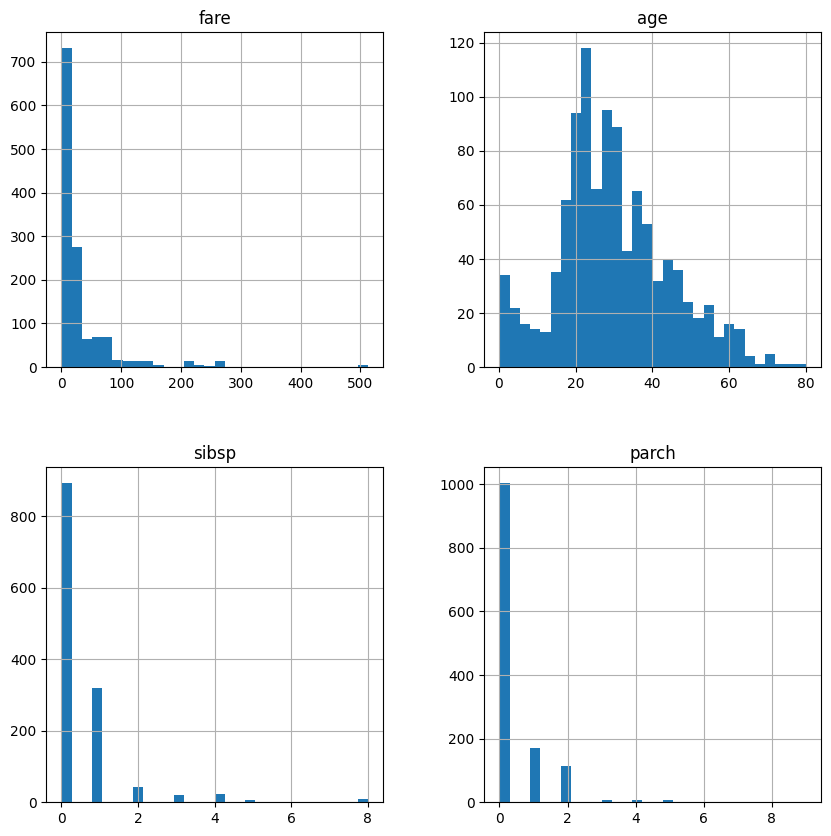

In [39]:
# add your code here
data[vars_num].hist(bins=30, figsize=(10,10))

#### ✅ Task for students: Separate data into train and test
use train_test_split from sklearn to divide train and test set, use 0.2 test and the remaining as train

In [41]:
from sklearn.model_selection import train_test_split
# add your code here
y = data[target]
X = data.drop(labels=(target), axis=1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Feature Engineering

#### ✅ Task for students: Extract only the letter (and drop the number) from the variable Cabin

In [42]:
# add your code here
def extract_cabin_letter(cabin_string):
    if cabin_string is np.nan:
        return np.nan
    else:
        for char in cabin_string:
            if char.isalpha():
                return char


X_train["cabin"] = X_train["cabin"].apply(extract_cabin_letter)
X_test["cabin"] = X_test["cabin"].apply(extract_cabin_letter)

X_train["cabin"].unique()

<StringArray>
[nan, 'E', 'C', 'B', 'A', 'F', 'D', 'G', 'T']
Length: 9, dtype: str

#### Fill in Missing data in numerical variables:

- Add a binary missing indicator
- Fill NA in original variable with the median

In [43]:
# add missing indicator for age variable
X_train['age'+'_NA'] = np.where(X_train['age'].isnull(), 1, 0)
X_test['age'+'_NA'] = np.where(X_test['age'].isnull(), 1, 0)

X_train.head()

,pclass,sex,age,sibsp,parch,fare,cabin,embarked,title,age_NA
772,3,male,17.0,0,0,7.8958,NaN,S,Mr,0
543,2,male,36.0,0,0,10.5000,NaN,S,Mr,0
289,1,female,18.0,0,2,79.6500,E,S,Miss,0
10,1,male,47.0,1,0,227.5250,C,C,Col,0
147,1,male,NaN,0,0,42.4000,NaN,S,Mr,1


In [46]:
# replace NaN by median you extracted from the training data
median_val = X_train['age'].median()

X_train['age'] = X_train['age'].fillna(median_val)
X_test['age'] = X_test['age'].fillna(median_val)

#### ✅ Task for students: add missing indicator for fare variable

In [45]:
# add your code here
X_train['fare'+'_NA'] = np.where(X_train['fare'].isnull(), 1, 0)
X_test['fare'+'_NA'] = np.where(X_test['fare'].isnull(), 1, 0)

#### ✅ Task for students: replace NaN by median you extracted from the training data

In [47]:
# add your code here
median_val = X_train['fare'].median()

X_train['fare'] = X_train['fare'].fillna(median_val)
X_test['fare'] = X_test['fare'].fillna(median_val)

X_train["fare_NA"].sum()

np.int64(1)

In [48]:
# check if the missing values were correctly replaced
X_train[['age', 'fare']].isnull().sum()

age     0
fare    0
dtype: int64

#### ✅ Task for students: Replace Missing data in categorical variables with the string **Missing**

In [49]:
# add your code here
X_train[vars_cat].isnull().sum()

for col in X_train[vars_cat].columns:
    X_train[col] = X_train[col].replace(to_replace=np.nan, value="Missing")
    X_test[col] = X_test[col].replace(to_replace=np.nan, value="Missing")

X_train["cabin"].unique()
X_test["cabin"].unique()

<StringArray>
['Missing', 'E', 'C', 'B', 'D', 'A', 'F']
Length: 7, dtype: str

check is there are any missing data in any of the variables in both test and train

In [50]:
X_train.isnull().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
cabin       0
embarked    0
title       0
age_NA      0
fare_NA     0
dtype: int64

In [51]:
X_test.isnull().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
cabin       0
embarked    0
title       0
age_NA      0
fare_NA     0
dtype: int64

#### ✅ Task for students: Remove rare labels in categorical variables
- print the different value counts for each of the categories in the cabin variable, what do you notice
- use the df[column].value_counts(normalize=True) to find the percentage of each category for each variable
- remove labels present in less than 5 % of the passengers

In [53]:
# add your code here
for var in vars_cat:
    val_counts = X_train[var].value_counts(normalize=True)
    print("------------------")    
    for val, p in val_counts.items():
        print(val, p)

        if p < 0.03:
            X_train[var] = X_train[var].replace(to_replace=val, value="agg_other")
            X_test[var] = X_test[var].replace(to_replace=val, value="agg_other")


------------------
3 0.542502387774594
1 0.2454632282712512
2 0.21203438395415472
------------------
male 0.6466093600764088
female 0.3533906399235912
------------------
Missing 0.7765042979942693
C 0.07163323782234957
agg_other 0.06303724928366762
B 0.049665711556829036
D 0.039159503342884434
------------------
S 0.7039159503342884
C 0.19961795606494748
Q 0.09551098376313276
agg_other 0.0009551098376313276
------------------
Mr 0.5778414517669532
Miss 0.19866284622731614
Mrs 0.1489971346704871
Master 0.04775549188156638
agg_other 0.026743075453677174


In [54]:
# print the cardinality of categorical variables
X_train[vars_cat].nunique()

pclass      3
sex         2
cabin       5
embarked    4
title       5
dtype: int64

In [55]:
# print the cardinality of categorical variables
X_test[vars_cat].nunique()

pclass      3
sex         2
cabin       5
embarked    4
title       5
dtype: int64

####  ✅ Task for students: Perform one hot encoding of categorical variables into k-1 binary variables

- k-1, means that if the variable contains 9 different categories, we create 8 different binary variables
- use OneHotEncoder from sklearn. The encoder will output a numpy array. You should use encoder.get_feature_names_out() to recreate a new dataframe
- remember to fit the encoder to the training data and to use it on the test data
- Remember to drop the original categorical variable (the one with the strings) after the encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder(drop="first", sparse_output=False).fit(X_train[vars_cat])

X_train_encoded = one_hot_encoder.transform(X_train[vars_cat])
X_test_encoded = one_hot_encoder.transform(X_test[vars_cat])


X_train_encoded_df = pd.DataFrame(data=X_train_encoded, columns=one_hot_encoder.get_feature_names_out(), index=X_train.index)
X_test_encoded_df = pd.DataFrame(data=X_test_encoded, columns=one_hot_encoder.get_feature_names_out(), index=X_test.index)



X_train_new = pd.concat([X_train[vars_num], X_train_encoded_df], axis=1)
X_test_new = pd.concat([X_test[vars_num], X_test_encoded_df], axis=1)



,pclass_2,pclass_3,sex_male,cabin_C,cabin_D,cabin_Missing,cabin_agg_other,embarked_Q,embarked_S,embarked_agg_other,title_Miss,title_Mr,title_Mrs,title_agg_other
772,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
543,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
289,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
10,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
147,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [66]:
# make sure both dataframes have the same columns with the same order (important for scaling)
X_train.columns==X_test.columns

X_test_new.head()

,fare,age,sibsp,parch,pclass_2,pclass_3,sex_male,cabin_C,cabin_D,cabin_Missing,cabin_agg_other,embarked_Q,embarked_S,embarked_agg_other,title_Miss,title_Mr,title_Mrs,title_agg_other
1148,7.1250,35.0,0,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1049,15.7417,20.0,1,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
982,7.8958,28.0,0,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
808,8.0500,28.0,0,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1195,7.7500,28.0,0,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


#### ✅ Task for students: Scale the variables
-  Use the standard scaler from Scikit-learn
-  make sure that you have the same order of variables in both train and test data
-  dont forget to use the same scaling parameters from the train data for the test data

In [ ]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
print(scaler.fit(X_train_new))

X_train_scaled_np = scaler.transform(X_train_new)
X_test_scaled_np = scaler.transform(X_test_new)

X_train_scaled = pd.DataFrame(data=X_train_scaled_np, columns=X_train_new.columns, index=X_train_new.index)
X_test_scaled = pd.DataFrame(data=X_test_scaled_np, columns=X_test_new.columns, index=X_test_new.index)

StandardScaler()


,fare,age,sibsp,parch,pclass_2,pclass_3,sex_male,cabin_C,cabin_D,cabin_Missing,cabin_agg_other,embarked_Q,embarked_S,embarked_agg_other,title_Miss,title_Mr,title_Mrs,title_agg_other
772,-0.495198,-0.956568,-0.495964,-0.442432,-0.518740,0.918319,0.739276,-0.277778,-0.20188,0.536491,-0.259381,-0.324956,0.648555,-0.03092,-0.497910,0.854739,-0.418431,-0.165765
543,-0.444889,0.529551,-0.495964,-0.442432,1.927749,-1.088946,0.739276,-0.277778,-0.20188,0.536491,-0.259381,-0.324956,0.648555,-0.03092,-0.497910,0.854739,-0.418431,-0.165765
289,0.890994,-0.878352,-0.495964,1.795376,-0.518740,-1.088946,-1.352675,-0.277778,-0.20188,-1.863963,3.855339,-0.324956,0.648555,-0.03092,2.008396,-1.169948,-0.418431,-0.165765
10,3.747734,1.389936,0.456833,-0.442432,-0.518740,-1.088946,0.739276,3.600000,-0.20188,-1.863963,-0.259381,-0.324956,-1.541888,-0.03092,-0.497910,-1.169948,-0.418431,6.032649
147,0.171375,-0.096184,-0.495964,-0.442432,-0.518740,-1.088946,0.739276,-0.277778,-0.20188,0.536491,-0.259381,-0.324956,0.648555,-0.03092,-0.497910,0.854739,-0.418431,-0.165765


#### ✅ Task for students: Train a Logistic Regression model from sklearn

- use sklearn to build a LogisticRegression model
- Set the regularization parameter to 0.0005
- Set the seed to 0 for reproducibility
- remember to train the model by using model.fit after you initialize it

In [ ]:
# import the model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=0.0005, random_state=0)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.0005
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Make predictions and evaluate model performance
Determine:
- accuracy
- roc-auc
on both training and test data. Try different options (weighted vs. micro vs. macro) and try to understand the differences

**Important, remember that to determine the accuracy, you need the outcome 0, 1, referring to survived or not. But to determine the roc-auc you need the probability of survival.**

In [ ]:
# to evaluate the models 
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score


# make predictions for train set
class_ = model.predict(X_train)
pred = model.predict_proba(X_train)[:,1]

# determine roc-auc and accuracy
print('train roc-auc: {}'.format(roc_auc_score(y_train, pred)))
print('train accuracy: {}'.format(accuracy_score(y_train, class_)))

print()

#### ✅ Task for students: make predictions for test set and print accuracy and roc-auc


In [5]:
# add your code here


### That's it! Well done